# Laboratorio #8 - Teoría de Probabilidades
Integrantes del grupo: Santiago Cordero (Carnet 24472) y Luis Pedro Hernández (Carnet 24337).
Sección: 30

## Etapa 3: Incorporación del presupuesto y costo

Simulación Monte Carlo del álbum reducido con límite de presupuesto. Parámetros del enunciado: `N = 100` estampas, `S = 7` estampas por sobre, precio por sobre `Q 9.50`, presupuesto `Q 1000`, `R = 10000` simulaciones y semilla `2026`.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

N = 100
S = 7
R = 10_000
SEED = 2026
PRECIO_SOBRE = 9.50
PRESUPUESTO = 1_000.00
SOBRES_CAJA = 104
COSTO_CAJA = 975.00

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def simular_presupuesto(
    n=N,
    s=S,
    presupuesto=PRESUPUESTO,
    precio_sobre=PRECIO_SOBRE,
    r=R,
    seed=SEED,
):
    """Compra sobres uno a uno hasta completar el album o agotar el presupuesto."""
    rng = np.random.default_rng(seed)
    max_sobres = math.floor(presupuesto / precio_sobre)

    completo = np.zeros(r, dtype=bool)
    sobres_comprados = np.zeros(r, dtype=int)
    estampas_distintas = np.zeros(r, dtype=int)
    repetidas = np.zeros(r, dtype=int)

    for i in range(r):
        album = np.zeros(n, dtype=bool)
        total_repetidas = 0

        for num_sobres in range(1, max_sobres + 1):
            sobre = rng.choice(n, size=s, replace=False)
            total_repetidas += int(album[sobre].sum())
            album[sobre] = True

            if album.all():
                completo[i] = True
                sobres_comprados[i] = num_sobres
                estampas_distintas[i] = n
                repetidas[i] = total_repetidas
                break

        if sobres_comprados[i] == 0:
            sobres_comprados[i] = max_sobres
            estampas_distintas[i] = int(album.sum())
            repetidas[i] = total_repetidas

    return completo, sobres_comprados, estampas_distintas, repetidas, max_sobres


def simular_sobres_fijos(m, n=N, s=S, r=R, seed=SEED):
    """Compra exactamente m sobres y verifica si el album queda completo."""
    rng = np.random.default_rng(seed)
    completo = np.zeros(r, dtype=bool)
    estampas_distintas = np.zeros(r, dtype=int)

    for i in range(r):
        album = np.zeros(n, dtype=bool)
        for _ in range(m):
            sobre = rng.choice(n, size=s, replace=False)
            album[sobre] = True
        completo[i] = album.all()
        estampas_distintas[i] = int(album.sum())

    return completo, estampas_distintas


def resumen_binario(completo):
    return np.array([np.mean(~completo), np.mean(completo)])

### 3.1 Compra de sobres sueltos con presupuesto de Q 1000

Se compra un sobre a la vez hasta completar el álbum o hasta que ya no alcance el presupuesto para comprar otro sobre.

Resultados con sobres sueltos y presupuesto de Q 1000
----------------------------------------------------------
Sobres maximos que permite el presupuesto: 105
Gasto maximo si no se completa antes: Q 997.50
Dinero sobrante si se compran 105 sobres: Q 2.50
Probabilidad estimada de completar el album: 0.9533 (95.33%)
Numero esperado de sobres comprados: 71.6998
Desviacion estandar de sobres comprados: 15.4425
Simulaciones no exitosas: 467 de 10000
Numero esperado de estampas distintas en casos no exitosos: 98.9807


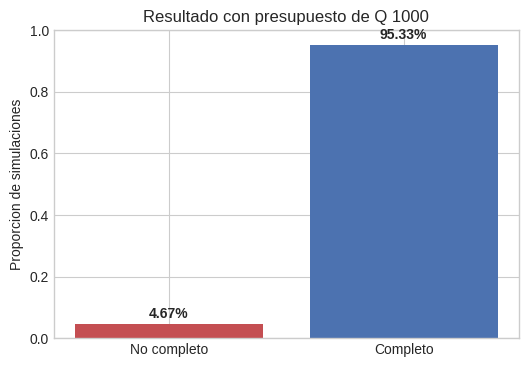

In [3]:
completo_presupuesto, sobres_presupuesto, distintas_presupuesto, repetidas_presupuesto, max_sobres_sueltos = simular_presupuesto()

prob_completar_presupuesto = completo_presupuesto.mean()
esperado_sobres = sobres_presupuesto.mean()
std_sobres = sobres_presupuesto.std(ddof=1)
fallos_presupuesto = ~completo_presupuesto
esperado_distintas_fallo = distintas_presupuesto[fallos_presupuesto].mean()

print("Resultados con sobres sueltos y presupuesto de Q 1000")
print("-" * 58)
print(f"Sobres maximos que permite el presupuesto: {max_sobres_sueltos}")
print(f"Gasto maximo si no se completa antes: Q {max_sobres_sueltos * PRECIO_SOBRE:,.2f}")
print(f"Dinero sobrante si se compran {max_sobres_sueltos} sobres: Q {PRESUPUESTO - max_sobres_sueltos * PRECIO_SOBRE:,.2f}")
print(f"Probabilidad estimada de completar el album: {prob_completar_presupuesto:.4f} ({prob_completar_presupuesto:.2%})")
print(f"Numero esperado de sobres comprados: {esperado_sobres:.4f}")
print(f"Desviacion estandar de sobres comprados: {std_sobres:.4f}")
print(f"Simulaciones no exitosas: {fallos_presupuesto.sum()} de {R}")
print(f"Numero esperado de estampas distintas en casos no exitosos: {esperado_distintas_fallo:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["No completo", "Completo"]
proporciones = resumen_binario(completo_presupuesto)
colors = ["#c44e52", "#4c72b0"]
ax.bar(labels, proporciones, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel("Proporcion de simulaciones")
ax.set_title("Resultado con presupuesto de Q 1000")
for idx, prop in enumerate(proporciones):
    ax.text(idx, prop + 0.02, f"{prop:.2%}", ha="center", fontweight="bold")
plt.show()

### Respuestas de análisis 1

1. Con Q 1000 se pueden comprar como máximo `floor(1000 / 9.50) = 105` sobres sueltos. Ese número contiene `105 * 7 = 735` estampas en total.
2. El mínimo teórico sin repetidas es `ceil(100 / 7) = 15` sobres. Por cantidad física de estampas, 105 sobres es más que suficiente; sin embargo, por las repetidas no se garantiza completar el álbum.
3. En esta simulación, aun con 105 sobres disponibles, la probabilidad estimada de completar el álbum fue aproximadamente `95.33%`, lo que muestra que el presupuesto es alto para el álbum reducido, pero no elimina por completo el riesgo de no completar.

### 3.2 Compra de una caja de 104 sobres

Ahora se compran exactamente 104 sobres por Q 975 y se verifica si el álbum queda completo al final de la caja.

Resultados comprando exactamente una caja de 104 sobres
----------------------------------------------------------
Costo de la caja: Q 975.00
Dinero sobrante respecto a Q 1000: Q 25.00
Probabilidad estimada de completar el album: 0.9482 (94.82%)
Simulaciones no exitosas: 518 de 10000
Estampas distintas promedio en casos no exitosos: 98.9788

Comparacion contra sobres sueltos con Q 1000
- Sobres sueltos: 0.9533 (95.33%)
- Caja de 104:    0.9482 (94.82%)
- Diferencia:     0.0051 puntos de probabilidad


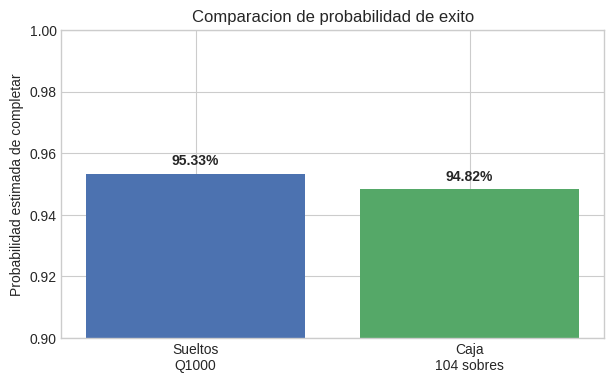

In [4]:
completo_caja, distintas_caja = simular_sobres_fijos(SOBRES_CAJA)
prob_completar_caja = completo_caja.mean()
fallos_caja = ~completo_caja

print("Resultados comprando exactamente una caja de 104 sobres")
print("-" * 58)
print(f"Costo de la caja: Q {COSTO_CAJA:,.2f}")
print(f"Dinero sobrante respecto a Q 1000: Q {PRESUPUESTO - COSTO_CAJA:,.2f}")
print(f"Probabilidad estimada de completar el album: {prob_completar_caja:.4f} ({prob_completar_caja:.2%})")
print(f"Simulaciones no exitosas: {fallos_caja.sum()} de {R}")
print(f"Estampas distintas promedio en casos no exitosos: {distintas_caja[fallos_caja].mean():.4f}")
print()
print("Comparacion contra sobres sueltos con Q 1000")
print(f"- Sobres sueltos: {prob_completar_presupuesto:.4f} ({prob_completar_presupuesto:.2%})")
print(f"- Caja de 104:    {prob_completar_caja:.4f} ({prob_completar_caja:.2%})")
print(f"- Diferencia:     {prob_completar_presupuesto - prob_completar_caja:.4f} puntos de probabilidad")

fig, ax = plt.subplots(figsize=(7, 4))
estrategias = ["Sueltos\nQ1000", "Caja\n104 sobres"]
probabilidades = [prob_completar_presupuesto, prob_completar_caja]
ax.bar(estrategias, probabilidades, color=["#4c72b0", "#55a868"])
ax.set_ylim(0.90, 1.00)
ax.set_ylabel("Probabilidad estimada de completar")
ax.set_title("Comparacion de probabilidad de exito")
for idx, prob in enumerate(probabilidades):
    ax.text(idx, prob + 0.003, f"{prob:.2%}", ha="center", fontweight="bold")
plt.show()

### Respuestas de análisis 2

La caja cuesta menos por sobre (`Q 975 / 104 = Q 9.375`) que comprar sobres sueltos (`Q 9.50`). Sin embargo, la simulación de la caja usa exactamente 104 sobres, mientras que el presupuesto de Q 1000 permite comprar 105 sobres sueltos.

Con los resultados obtenidos, la caja tuvo una probabilidad estimada de completar de aproximadamente `94.82%`, mientras que comprar sobres sueltos con Q 1000 dio aproximadamente `95.33%`. Si el criterio es maximizar la probabilidad de completar el álbum, la caja sola no conviene frente a usar el presupuesto en sobres sueltos. Si el criterio incluye gastar menos, la caja es casi igual de efectiva y deja Q 25 sin usar.

### 3.3 Estrategia mixta: caja + sobres sueltos

Se analiza el dinero sobrante al comprar una caja y se propone usarlo en sobres sueltos adicionales sin exceder Q 1000.

Estrategia mixta propuesta
----------------------------------------------------------
Comprar 1 caja: 104 sobres por Q 975.00
Sobrante despues de la caja: Q 25.00
Sobres sueltos adicionales posibles: 2
Sobres totales con estrategia mixta: 106
Costo total de la estrategia mixta: Q 994.00
Presupuesto no gastado: Q 6.00
Probabilidad estimada de completar el album: 0.9567 (95.67%)
Simulaciones no exitosas: 433 de 10000
Estampas distintas promedio en casos no exitosos: 98.9861

Resumen de estrategias
Estrategia                 Sobres      Costo   Sobrante   P(completar)
------------------------------------------------------------------------
Sueltos hasta Q1000           105     997.50       2.50         0.9533
Caja sola                     104     975.00      25.00         0.9482
Caja + sueltos                106     994.00       6.00         0.9567


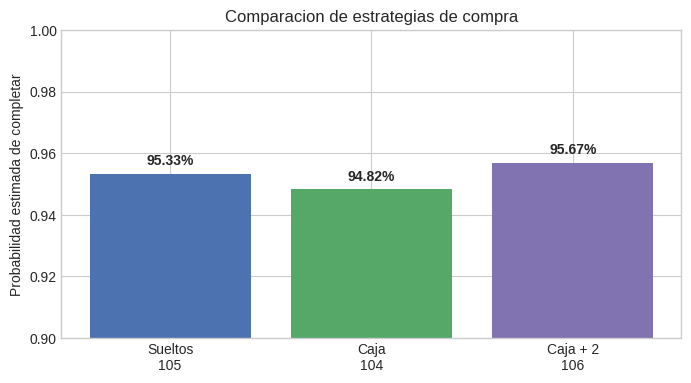

In [5]:
sobrante_caja = PRESUPUESTO - COSTO_CAJA
sobres_extra = math.floor(sobrante_caja / PRECIO_SOBRE)
sobres_mixtos = SOBRES_CAJA + sobres_extra
costo_mixto = COSTO_CAJA + sobres_extra * PRECIO_SOBRE
sobrante_mixto = PRESUPUESTO - costo_mixto

completo_mixto, distintas_mixto = simular_sobres_fijos(sobres_mixtos)
prob_completar_mixto = completo_mixto.mean()
fallos_mixto = ~completo_mixto

print("Estrategia mixta propuesta")
print("-" * 58)
print(f"Comprar 1 caja: {SOBRES_CAJA} sobres por Q {COSTO_CAJA:,.2f}")
print(f"Sobrante despues de la caja: Q {sobrante_caja:,.2f}")
print(f"Sobres sueltos adicionales posibles: {sobres_extra}")
print(f"Sobres totales con estrategia mixta: {sobres_mixtos}")
print(f"Costo total de la estrategia mixta: Q {costo_mixto:,.2f}")
print(f"Presupuesto no gastado: Q {sobrante_mixto:,.2f}")
print(f"Probabilidad estimada de completar el album: {prob_completar_mixto:.4f} ({prob_completar_mixto:.2%})")
print(f"Simulaciones no exitosas: {fallos_mixto.sum()} de {R}")
print(f"Estampas distintas promedio en casos no exitosos: {distintas_mixto[fallos_mixto].mean():.4f}")

print("Resumen de estrategias")
print(f"{'Estrategia':<24} {'Sobres':>8} {'Costo':>10} {'Sobrante':>10} {'P(completar)':>14}")
print("-" * 72)
print(f"{'Sueltos hasta Q1000':<24} {max_sobres_sueltos:>8} {max_sobres_sueltos * PRECIO_SOBRE:>10.2f} {PRESUPUESTO - max_sobres_sueltos * PRECIO_SOBRE:>10.2f} {prob_completar_presupuesto:>14.4f}")
print(f"{'Caja sola':<24} {SOBRES_CAJA:>8} {COSTO_CAJA:>10.2f} {PRESUPUESTO - COSTO_CAJA:>10.2f} {prob_completar_caja:>14.4f}")
print(f"{'Caja + sueltos':<24} {sobres_mixtos:>8} {costo_mixto:>10.2f} {sobrante_mixto:>10.2f} {prob_completar_mixto:>14.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
estrategias = ["Sueltos\n105", "Caja\n104", "Caja + 2\n106"]
probabilidades = [prob_completar_presupuesto, prob_completar_caja, prob_completar_mixto]
ax.bar(estrategias, probabilidades, color=["#4c72b0", "#55a868", "#8172b2"])
ax.set_ylim(0.90, 1.00)
ax.set_ylabel("Probabilidad estimada de completar")
ax.set_title("Comparacion de estrategias de compra")
for idx, prob in enumerate(probabilidades):
    ax.text(idx, prob + 0.003, f"{prob:.2%}", ha="center", fontweight="bold")
plt.show()

### Respuestas de análisis 3

Comprar solo la caja deja `Q 25.00` sin gastar. Como cada sobre suelto cuesta Q 9.50, ese sobrante alcanza para `2` sobres adicionales, usando Q 19.00 y dejando `Q 6.00` sin gastar.

La estrategia mixta propuesta es comprar `1 caja + 2 sobres sueltos`, para un total de `106` sobres y un costo de `Q 994.00`. Esta estrategia usa el presupuesto de forma más eficiente que la caja sola y también permite comprar un sobre más que la estrategia de sobres sueltos únicamente, que llega a 105 sobres.

En la simulación, la estrategia mixta obtuvo una probabilidad estimada de completar de aproximadamente `95.67%`, mayor que la caja sola y ligeramente mayor que comprar sobres sueltos hasta agotar el presupuesto. Por lo tanto, bajo este modelo, la estrategia mixta es la mejor de las tres para maximizar la probabilidad de completar el álbum sin exceder Q 1000.